#  Cargar todos los archivos CSV que se encuentran en la carpeta GuardarDatos. Luego los uniremos en una sola tabla.

Este notebook realiza las siguientes tareas:

Carga los archivos CSV de la carpeta GuardarDatos.

Une todos los archivos en un solo DataFrame.

Verifica y muestra los duplicados basados en el tweet_id.

Elimina los duplicados.

Reemplaza el tweet_id por un índice numérico único.

Guarda los datos procesados en un nuevo archivo CSV.

# Codigo Depurado

Visualización de valores nulos:

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tweet_id              342 non-null    object 
 1   tweet_text            342 non-null    object 
 2   comentario            342 non-null    object 
 3   comentario_autor      342 non-null    object 
 4   fecha_publicacion     342 non-null    object 
 5   timestamp_extraccion  342 non-null    object 
 6   replies               329 non-null    float64
 7   reposts               342 non-null    int64  
 8   likes                 342 non-null    int64  
 9   views                 342 non-null    int64  
 10  tweet_id_nuevo        24 non-null     float64
 11  clasificacion         24 non-null     object 
dtypes: float64(2), int64(3), object(7)
memory usage: 32.2+ KB

Valores nulos por columna:
 tweet_id                  0
t

C:\Users\home\AppData\Local\Temp\ipykernel_14644\1303621193.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['tweet_id_nuevo'] = range(1, len(df_limpio) + 1)


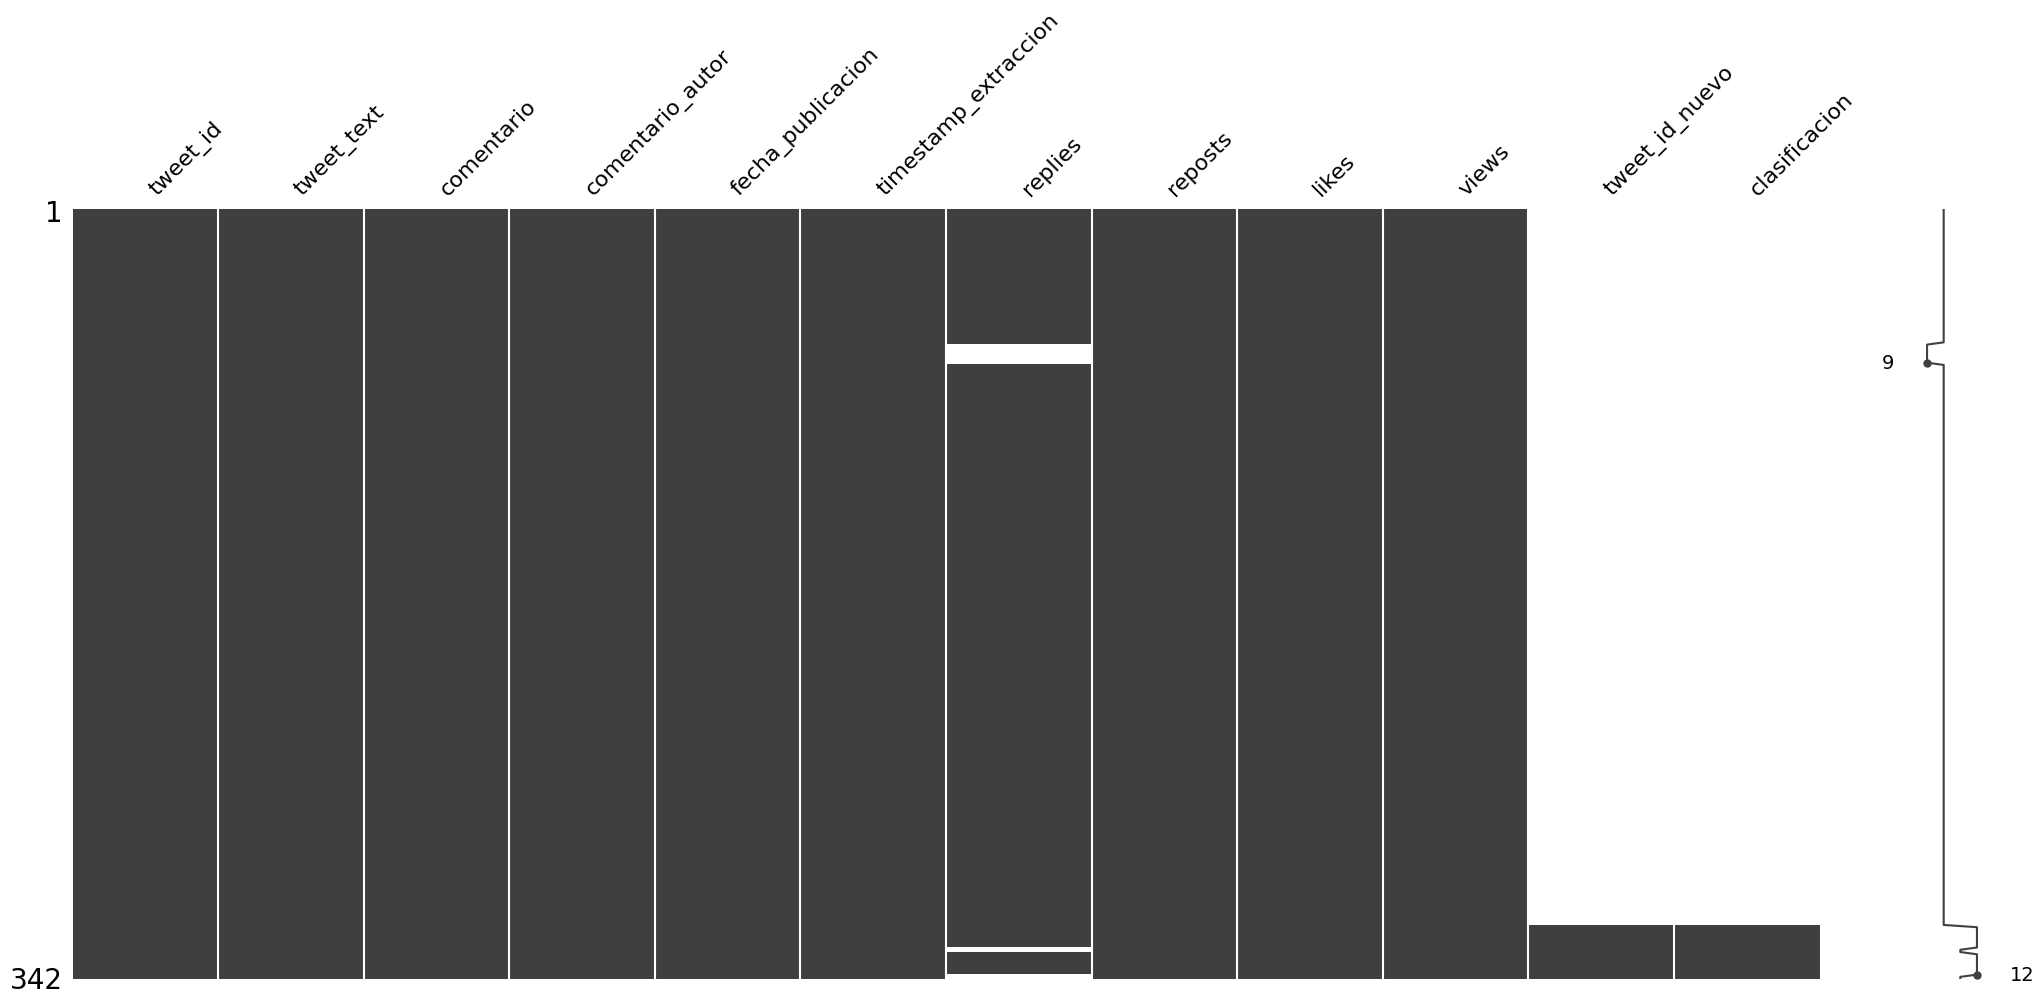

In [2]:
# Importar librerías necesarias
import os
import pandas as pd
import missingno as msno

# Definir ruta de la carpeta que contiene los archivos CSV
folder_path = '../db/'

# Paso 1: Cargar y concatenar los archivos CSV
def cargar_datos_csv(carpeta):
    archivos_csv = [f for f in os.listdir(carpeta) if f.endswith('.csv')]
    lista_df = [pd.read_csv(os.path.join(carpeta, archivo)) for archivo in archivos_csv]
    df_concatenado = pd.concat(lista_df, ignore_index=True)
    return df_concatenado

df = cargar_datos_csv(folder_path)

# Paso 2: Visualizar valores nulos
print("Visualización de valores nulos:")
msno.matrix(df)

print("\nInformación del DataFrame:")
df.info()

nulos = df.isnull().sum()
print("\nValores nulos por columna:\n", nulos)

# Paso 3: Verificar duplicados
duplicados_comentario = df[df.duplicated(subset='comentario', keep=False)]
print("\nDuplicados en la columna 'comentario':")
print(duplicados_comentario.head(10))
print("\nCantidad de duplicados en 'comentario':", duplicados_comentario.shape[0])

duplicados_totales = df[df.duplicated(keep=False)]
print("\nDuplicados en todas las columnas:", duplicados_totales.shape[0])

# Paso 4: Eliminar duplicados
df_limpio = df.drop_duplicates(keep='first')
print("\nCantidad de registros después de eliminar duplicados:", df_limpio.shape[0])

# Paso 5: Crear nueva columna con ID único
df_limpio['tweet_id_nuevo'] = range(1, len(df_limpio) + 1)

# Paso 6: Guardar el DataFrame limpio
output_file = os.path.join(folder_path, 'tweets_limpios.csv')
df_limpio.to_csv(output_file, index=False)

print(f"\n✅ Datos limpios guardados en: {output_file}")


# Limpieza de comentarios

Visualización de valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809 entries, 0 to 808
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tweet_id              809 non-null    object 
 1   tweet_text            809 non-null    object 
 2   comentario            807 non-null    object 
 3   comentario_autor      809 non-null    object 
 4   fecha_publicacion     809 non-null    object 
 5   timestamp_extraccion  809 non-null    object 
 6   replies               779 non-null    float64
 7   reposts               809 non-null    int64  
 8   likes                 809 non-null    int64  
 9   views                 809 non-null    int64  
 10  tweet_id_nuevo        491 non-null    float64
 11  clasificacion         36 non-null     object 
dtypes: float64(2), int64(3), object(7)
memory usage: 76.0+ KB

✅ Datos limpios guardados en: ../db/comentarios_limpios.csv
Comentarios nulos: 0
Come

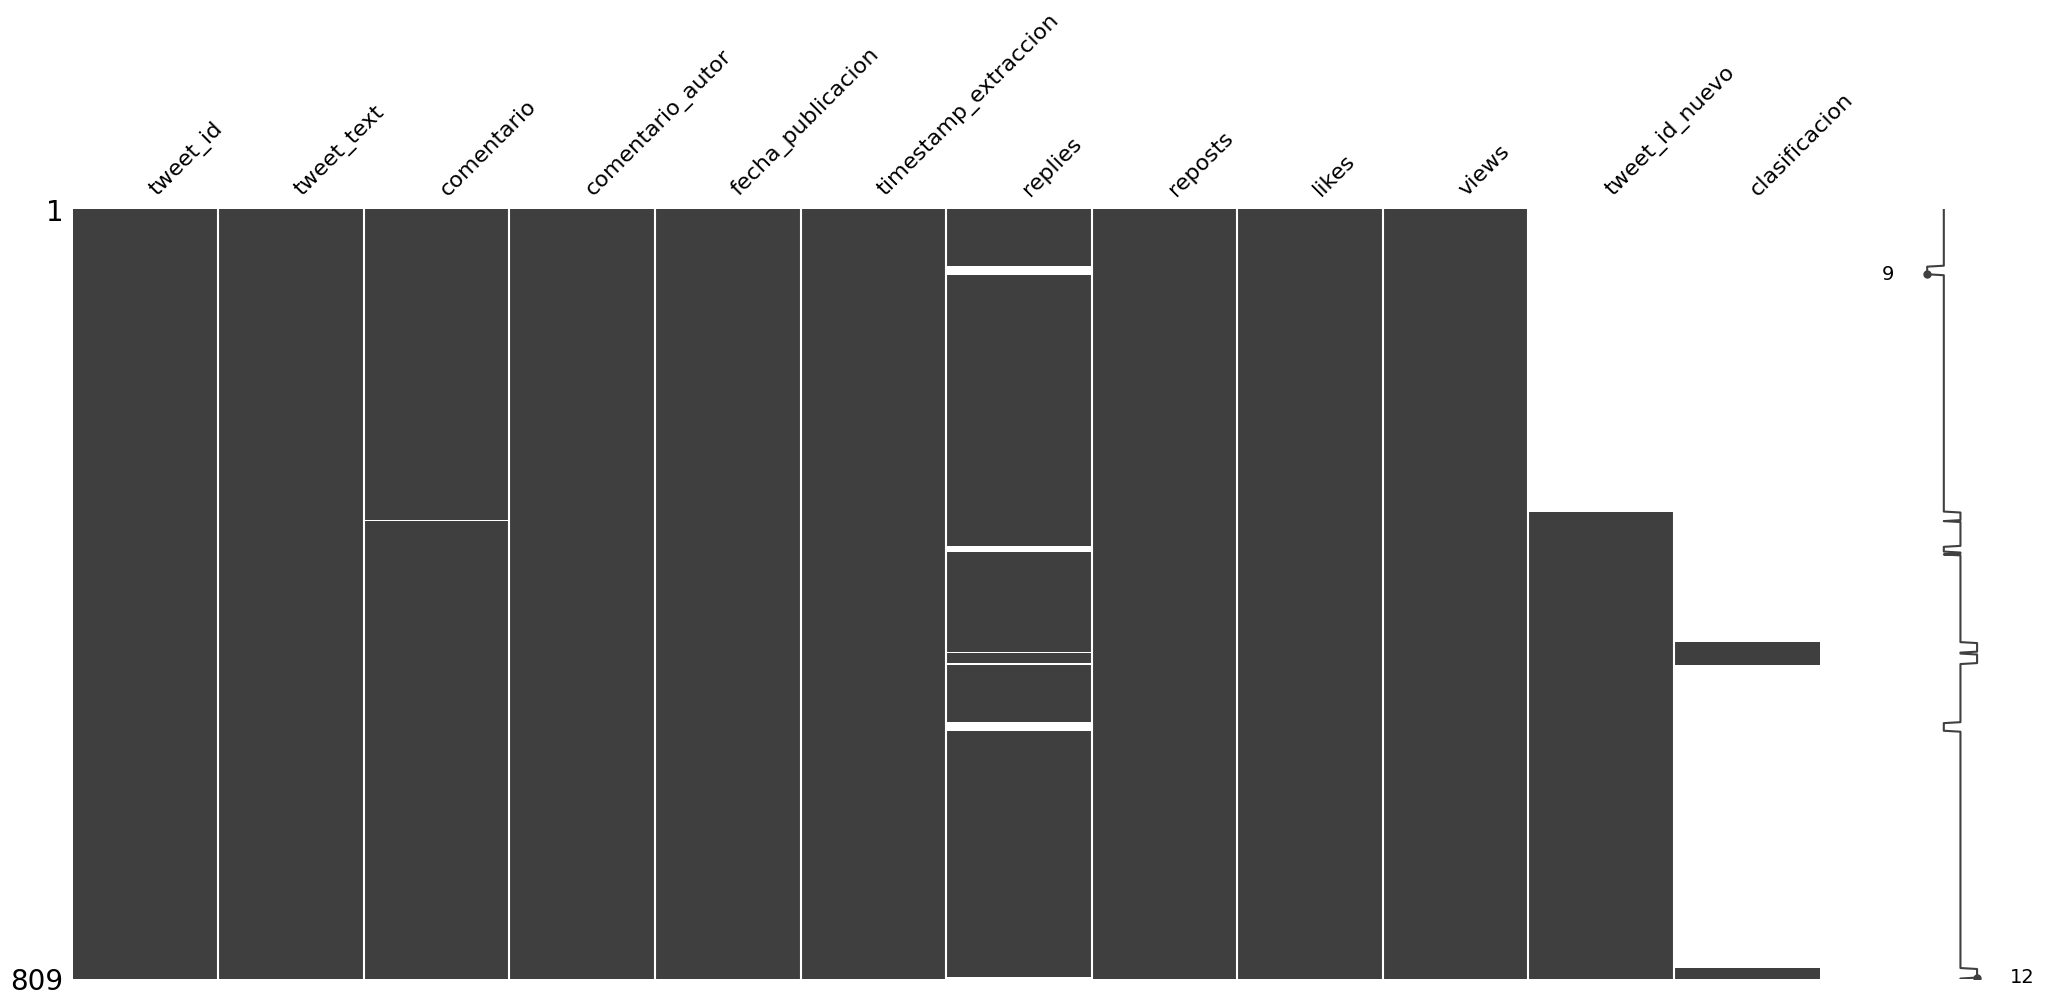

In [4]:
# Importar librerías necesarias
import os
import pandas as pd
import missingno as msno
import re

# Ruta de la carpeta donde están los CSV
folder_path = '../db/'

# Función para cargar y concatenar CSVs
def cargar_datos_csv(carpeta):
    archivos_csv = [f for f in os.listdir(carpeta) if f.endswith('.csv')]
    lista_df = [pd.read_csv(os.path.join(carpeta, archivo)) for archivo in archivos_csv]
    return pd.concat(lista_df, ignore_index=True)

# Función para limpiar texto
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)  # eliminar URLs
    texto = re.sub(r'[^a-zA-Záéíóúüñ0-9\s]', '', texto)  # quitar símbolos
    texto = re.sub(r'\s+', ' ', texto).strip()           # quitar espacios extras
    return texto

# Cargar los datos
df = cargar_datos_csv(folder_path)

# Visualizar nulos
print("Visualización de valores nulos:")
msno.matrix(df)
df.info()

# --- LIMPIEZA DEL CAMPO COMENTARIO ---
# 1. Eliminar filas con comentario nulo o vacío
df = df.dropna(subset=['comentario'])
df = df[df['comentario'].str.strip() != '']

# 2. Eliminar duplicados en comentario
df = df.drop_duplicates(subset='comentario', keep='first')

# 3. Limpiar texto del comentario
df['comentario'] = df['comentario'].apply(limpiar_texto)

# 4. Crear ID nuevo
df['tweet_id_nuevo'] = range(1, len(df) + 1)

# 5. Guardar archivo limpio
output_file = os.path.join(folder_path, 'comentarios_limpios.csv')
df.to_csv(output_file, index=False)

# 6. Validar limpieza
print("\n✅ Datos limpios guardados en:", output_file)
print("Comentarios nulos:", df['comentario'].isnull().sum())
print("Comentarios vacíos:", (df['comentario'].str.strip() == '').sum())
print("Total de comentarios únicos:", df.shape[0])
